<a href="https://colab.research.google.com/github/KartikMantri/U-Kan-repo/blob/main/unet_with_pretrained_basic_encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import time
import numpy as np
from PIL import Image
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


In [4]:
# Upload your kaggle.json (Kaggle account -> Settings -> API -> Create New Token)
from google.colab import files
print("Upload your kaggle.json now:")
uploaded = files.upload()  # select kaggle.json in the file picker

import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!pip install -q kaggle

Upload your kaggle.json now:


Saving kaggle.json to kaggle.json


In [4]:
# Dataset: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
# (contains ORIGA, REFUGE, and G1020 fundus images + OD/OC masks)
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/kaggle_data --unzip

# Inspect what actually got downloaded before wiring up paths below
import os
for root, dirs, filenames in os.walk("/content/kaggle_data"):
    depth = root.replace("/content/kaggle_data", "").count(os.sep)
    if depth <= 2:  # keep it readable, don't dump every file
        print("  " * depth + os.path.basename(root) + "/")
        for f in filenames[:5]:
            print("  " * (depth + 1) + f)
        if len(filenames) > 5:
            print("  " * (depth + 1) + f"... ({len(filenames)} files total)")

Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [00:57<00:00, 104MB/s]

kaggle_data/
  models/
    refuge_segmentation.pth
    refuge_clf.pkl
  ORIGA/
    origa_info.csv
    OrigaList.csv
    Masks_Square/
      004.png
      106.png
      223.png
      310.png
      642.png
      ... (651 files total)
    Images_Square/
      576.jpg
      009.jpg
      497.jpg
      043.jpg
      513.jpg
      ... (651 files total)
    Masks_Cropped/
      004.png
      106.png
      223.png
      310.png
      642.png
      ... (650 files total)
    Images/
      576.jpg
      009.jpg
      497.jpg
      043.jpg
      513.jpg
      ... (650 files total)
    Masks/
      004.png
      106.png
      223.png
      310.png
      642.png
      ... (650 files total)
    Semi-automatic-annotations/
      512.mat
      407.mat
      271.mat
      012.mat
      375.mat
      ... (652 files total)

In [5]:
import json, numpy as np
from PIL import Image

REFUGE_ROOT = "/content/kaggle_data/REFUGE"

# 1. What's inside the split index.json files?
for split in ["train", "val", "test"]:
    path = f"{REFUGE_ROOT}/{split}/index.json"
    with open(path) as f:
        data = json.load(f)
    print(f"--- {split}/index.json ---")
    print(f"type: {type(data)}")
    if isinstance(data, dict):
        print(f"keys (first 5): {list(data.keys())[:5]}")
        first_key = list(data.keys())[0]
        print(f"sample entry: {first_key} -> {data[first_key]}")
    elif isinstance(data, list):
        print(f"length: {len(data)}")
        print(f"sample entries: {data[:5]}")
    print()

# 2. What raw pixel values actually show up in the masks?
import os
mask_dir = f"{REFUGE_ROOT}/Masks_Square"
sample_masks = sorted(os.listdir(mask_dir))[:5]
for fname in sample_masks:
    m = np.array(Image.open(os.path.join(mask_dir, fname)))
    print(f"{fname}: shape={m.shape}, dtype={m.dtype}, unique values={np.unique(m)}")

--- train/index.json ---
type: <class 'dict'>
keys (first 5): ['0', '1', '2', '3', '4']
sample entry: 0 -> {'ImgName': 'g0001.jpg', 'Fovea_X': 1057.95, 'Fovea_Y': 1076.52, 'Size_X': 2124, 'Size_Y': 2056, 'Label': 1}

--- val/index.json ---
type: <class 'dict'>
keys (first 5): ['0', '1', '2', '3', '4']
sample entry: 0 -> {'ImgName': 'V0001.jpg', 'Label': 0, 'Fovea_X': 1050.07, 'Fovea_Y': 858.55, 'Size_X': 1634, 'Size_Y': 1634}

--- test/index.json ---
type: <class 'dict'>
keys (first 5): ['0', '1', '2', '3', '4']
sample entry: 0 -> {'ImgName': 'T0001.jpg', 'Size_X': 1634, 'Size_Y': 1634}

T0001.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]
T0002.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]
T0003.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]
T0004.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]
T0005.png: shape=(1634, 1634), dtype=uint8, unique values=[0 1 2]


In [6]:
import json, numpy as np
from PIL import Image
import os

REFUGE_ROOT = "/content/kaggle_data/REFUGE"

# 1. Infer which integer = which class by pixel count proportions
mask_dir = f"{REFUGE_ROOT}/Masks_Square"
sample_masks = sorted(os.listdir(mask_dir))[:20]
totals = {0: 0, 1: 0, 2: 0}
for fname in sample_masks:
    m = np.array(Image.open(os.path.join(mask_dir, fname)))
    vals, counts = np.unique(m, return_counts=True)
    for v, c in zip(vals, counts):
        totals[int(v)] += int(c)

print("Pixel totals across 20 sample masks (label -> total pixel count):")
for label, count in sorted(totals.items(), key=lambda x: -x[1]):
    print(f"  {label}: {count:,}")
print("\nExpect: largest count = background, middle = disc, smallest = cup")

# 2. Inspect the split index.json files
for split in ["train", "val", "test"]:
    path = f"{REFUGE_ROOT}/{split}/index.json"
    with open(path) as f:
        data = json.load(f)
    print(f"\n--- {split}/index.json ---")
    print(f"type: {type(data)}")
    if isinstance(data, dict):
        keys = list(data.keys())
        print(f"count: {len(keys)}, sample keys: {keys[:3]}")
        print(f"sample entry: {keys[0]} -> {data[keys[0]]}")
    elif isinstance(data, list):
        print(f"count: {len(data)}, sample entries: {data[:3]}")

Pixel totals across 20 sample masks (label -> total pixel count):
  0: 52,563,734
  1: 605,010
  2: 230,376

Expect: largest count = background, middle = disc, smallest = cup

--- train/index.json ---
type: <class 'dict'>
count: 400, sample keys: ['0', '1', '2']
sample entry: 0 -> {'ImgName': 'g0001.jpg', 'Fovea_X': 1057.95, 'Fovea_Y': 1076.52, 'Size_X': 2124, 'Size_Y': 2056, 'Label': 1}

--- val/index.json ---
type: <class 'dict'>
count: 400, sample keys: ['0', '1', '2']
sample entry: 0 -> {'ImgName': 'V0001.jpg', 'Label': 0, 'Fovea_X': 1050.07, 'Fovea_Y': 858.55, 'Size_X': 1634, 'Size_Y': 1634}

--- test/index.json ---
type: <class 'dict'>
count: 400, sample keys: ['0', '1', '2']
sample entry: 0 -> {'ImgName': 'T0001.jpg', 'Size_X': 1634, 'Size_Y': 1634}


In [7]:
import os

print("Does /content/kaggle_data exist?", os.path.exists("/content/kaggle_data"))
print("Does /content/kaggle_data/REFUGE exist?", os.path.exists("/content/kaggle_data/REFUGE"))
if os.path.exists("/content/kaggle_data/REFUGE"):
    print("Contents of REFUGE/:", os.listdir("/content/kaggle_data/REFUGE"))

print("\nDoes /content/data exist?", os.path.exists("/content/data"))
if os.path.exists("/content/data"):
    for root, dirs, fnames in os.walk("/content/data"):
        print(root, "->", len(fnames), "files")

Does /content/kaggle_data exist? True
Does /content/kaggle_data/REFUGE exist? True
Contents of REFUGE/: ['Masks_Square', 'Images_Square', 'val', 'train', 'test']

Does /content/data exist? False


In [11]:
REFUGE_ROOT = "/content/kaggle_data/REFUGE"
OUT_ROOT = "/content/data"

def organize_split(split_name):
    with open(f"{REFUGE_ROOT}/{split_name}/index.json") as f:
        index = json.load(f)

    img_out = f"{OUT_ROOT}/{split_name}/images"
    mask_out = f"{OUT_ROOT}/{split_name}/masks"
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(mask_out, exist_ok=True)

    n_ok, n_missing = 0, 0
    for entry in index.values():
        stem = os.path.splitext(entry["ImgName"])[0]
        src_img = f"{REFUGE_ROOT}/Images_Square/{stem}.jpg"
        src_mask = f"{REFUGE_ROOT}/Masks_Square/{stem}.png"

        if not (os.path.exists(src_img) and os.path.exists(src_mask)):
            n_missing += 1
            continue

        dst_img = f"{img_out}/{stem}.jpg"
        dst_mask = f"{mask_out}/{stem}.png"
        if not os.path.exists(dst_img):
            os.symlink(src_img, dst_img)
        if not os.path.exists(dst_mask):
            os.symlink(src_mask, dst_mask)
        n_ok += 1

    print(f"{split_name}: {n_ok} pairs linked, {n_missing} missing")

for split in ["train", "val", "test"]:
    organize_split(split)

train: 400 pairs linked, 0 missing
val: 400 pairs linked, 0 missing
test: 400 pairs linked, 0 missing


In [12]:
#cell 5
IMG_SIZE = 256
NUM_CLASSES = 3  # 0=background, 1=disc, 2=cup

CONFIG = dict(
    train_image_dir="/content/data/train/images",
    train_mask_dir="/content/data/train/masks",
    val_image_dir="/content/data/val/images",
    val_mask_dir="/content/data/val/masks",
    # confirmed via pixel-count check: masks are already {0=bg,1=disc,2=cup},
    # so no raw-value remapping is needed for this Kaggle repackaging.
    mask_format="already_012",
    batch_size=8,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    num_workers=2,
    checkpoint_path="/content/best_unet.pth",
    device="cuda" if torch.cuda.is_available() else "cpu",
)

In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class FundusSegDataset(Dataset):
    """
    image_dir/  -> RGB fundus images (.jpg)
    mask_dir/   -> single-channel masks (.png), same filename stem,
                   pixel values already {0,1,2} = {bg, disc, cup}.

    Back to plain 3-channel RGB (dropped the Sobel channel) - a pretrained
    ImageNet encoder's first-layer weights are only meaningful for 3
    RGB channels; adding a 4th channel would dilute that pretraining
    benefit, and ImageNet-pretrained features already include strong
    edge-sensitivity anyway.

    Also normalizes with ImageNet mean/std - the pretrained encoder was
    trained on inputs normalized this way, so skipping this step would
    silently hurt the pretrained weights' effectiveness.
    """
    def __init__(self, image_dir, mask_dir, filenames, mask_format="already_012",
                 img_size=IMG_SIZE, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.mask_format = mask_format
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.filenames)

    def _load_mask(self, mask_path):
        mask = Image.open(mask_path)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask = np.array(mask)
        if mask.ndim == 3:
            mask = mask[..., 0]
        return mask.astype(np.uint8)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(self.image_dir, fname)
        stem = os.path.splitext(fname)[0]

        mask_path = None
        for ext in [".png", ".bmp", ".jpg", ".jpeg", ".tif"]:
            cand = os.path.join(self.mask_dir, stem + ext)
            if os.path.exists(cand):
                mask_path = cand
                break
        if mask_path is None:
            raise FileNotFoundError(f"No mask found for {fname} in {self.mask_dir}")

        image = Image.open(img_path).convert("RGB")
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        image = np.array(image).astype(np.float32) / 255.0

        mask = self._load_mask(mask_path)

        if self.augment:
            image, mask = self._augment(image, mask)

        # ImageNet normalization - required for the pretrained encoder
        mean = np.array(IMAGENET_MEAN, dtype=np.float32)
        std = np.array(IMAGENET_STD, dtype=np.float32)
        image = (image - mean) / std

        image = torch.from_numpy(image).permute(2, 0, 1).float()  # [3,H,W]
        mask = torch.from_numpy(mask).long()
        return image, mask

    def _augment(self, image, mask):
        if np.random.rand() < 0.5:
            image = np.ascontiguousarray(image[:, ::-1, :])
            mask = np.ascontiguousarray(mask[:, ::-1])
        if np.random.rand() < 0.5:
            image = np.ascontiguousarray(image[::-1, :, :])
            mask = np.ascontiguousarray(mask[::-1, :])
        return image, mask

In [14]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00


In [15]:
# cell 7
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = nn.functional.pad(x, [diff_x // 2, diff_x - diff_x // 2,
                                   diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES, base=32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.down4 = Down(base * 8, base * 16)

        self.up1 = Up(base * 16, base * 8)
        self.up2 = Up(base * 8, base * 4)
        self.up3 = Up(base * 4, base * 2)
        self.up4 = Up(base * 2, base)

        self.outc = nn.Conv2d(base, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)  # raw logits, no softmax
        return logits

In [16]:
#cell 8
class ConfusionMatrixMeter:
    """
    Accumulates one confusion matrix over an entire epoch/split, then
    computes precision/recall/F1/dice/IoU ONCE from the totals. This is
    the correct way to do it - averaging per-batch metrics is wrong when
    class pixel counts vary a lot between batches (cup pixels are a tiny
    fraction of each image).
    """
    def __init__(self, num_classes: int):
        self.num_classes = num_classes
        self.reset()

    def reset(self):
        self.cm = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    @torch.no_grad()
    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        preds = preds.detach().cpu().numpy().reshape(-1)
        targets = targets.detach().cpu().numpy().reshape(-1)
        n = self.num_classes
        idx = n * targets.astype(np.int64) + preds.astype(np.int64)
        cm = np.bincount(idx, minlength=n * n).reshape(n, n)
        self.cm += cm

    def compute(self):
        # rows = ground truth, cols = predicted
        cm = self.cm.astype(np.float64)
        n = self.num_classes
        eps = 1e-7

        precision = np.zeros(n)
        recall = np.zeros(n)
        f1 = np.zeros(n)
        dice = np.zeros(n)
        iou = np.zeros(n)

        for c in range(n):
            tp = cm[c, c]
            fp = cm[:, c].sum() - tp
            fn = cm[c, :].sum() - tp

            precision[c] = tp / (tp + fp + eps)
            recall[c] = tp / (tp + fn + eps)
            f1[c] = 2 * precision[c] * recall[c] / (precision[c] + recall[c] + eps)
            dice[c] = 2 * tp / (2 * tp + fp + fn + eps)  # note: == f1[c] for binary-per-class
            iou[c] = tp / (tp + fp + fn + eps)

        pixel_acc = np.trace(cm) / (cm.sum() + eps)

        return {
            "precision_per_class": precision,
            "recall_per_class": recall,
            "f1_per_class": f1,
            "dice_per_class": dice,
            "iou_per_class": iou,
            "precision_macro": precision.mean(),
            "recall_macro": recall.mean(),
            "f1_macro": f1.mean(),
            "dice_macro": dice.mean(),
            "iou_macro": iou.mean(),
            # background dominates pixel count and inflates macro scores,
            # so disc+cup only mean is reported separately - it's the
            # number you actually care about clinically.
            "dice_disc_cup_mean": dice[1:].mean(),
            "iou_disc_cup_mean": iou[1:].mean(),
            "pixel_accuracy": pixel_acc,
        }


CLASS_NAMES = ["background", "disc", "cup"]


def format_metrics(metrics: dict, prefix: str = "") -> str:
    lines = [f"{prefix}pixel_acc={metrics['pixel_accuracy']:.4f}  "
             f"dice_macro={metrics['dice_macro']:.4f}  "
             f"dice(disc+cup)={metrics['dice_disc_cup_mean']:.4f}"]
    for i, name in enumerate(CLASS_NAMES):
        lines.append(
            f"    {name:12s}  "
            f"P={metrics['precision_per_class'][i]:.4f}  "
            f"R={metrics['recall_per_class'][i]:.4f}  "
            f"F1={metrics['f1_per_class'][i]:.4f}  "
            f"Dice={metrics['dice_per_class'][i]:.4f}  "
            f"IoU={metrics['iou_per_class'][i]:.4f}"
        )
    return "\n".join(lines)

In [17]:
#cell 9
train_files = sorted(os.listdir(CONFIG["train_image_dir"]))
val_files = sorted(os.listdir(CONFIG["val_image_dir"]))

train_ds = FundusSegDataset(
    CONFIG["train_image_dir"], CONFIG["train_mask_dir"], train_files,
    mask_format=CONFIG["mask_format"], img_size=IMG_SIZE, augment=True,
)
val_ds = FundusSegDataset(
    CONFIG["val_image_dir"], CONFIG["val_mask_dir"], val_files,
    mask_format=CONFIG["mask_format"], img_size=IMG_SIZE, augment=False,
)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                           num_workers=CONFIG["num_workers"], pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=CONFIG["num_workers"], pin_memory=True)

print(f"Train images: {len(train_ds)}, Val images: {len(val_ds)}")

Train images: 400, Val images: 400


In [18]:
import torch.nn.functional as F

class DiceLoss(nn.Module):
    """
    Multi-class soft Dice loss, computed directly from softmax probabilities
    so it's differentiable (unlike the Dice METRIC in metrics.py, which
    uses hard argmax predictions purely for reporting).
    """
    def __init__(self, num_classes: int, smooth: float = 1e-5):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = (probs * targets_onehot).sum(dims)
        cardinality = probs.sum(dims) + targets_onehot.sum(dims)

        dice_per_class = (2 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1 - dice_per_class.mean()


class CombinedLoss(nn.Module):
    """
    loss = ce_weight * CrossEntropy + dice_weight * DiceLoss

    CE treats every pixel equally, which is dominated by background
    (>95% of pixels) - that's why pixel accuracy was already 0.99+ while
    disc/cup Dice stayed low. Dice loss directly optimizes overlap
    regardless of class size, pushing the model to actually get the small
    classes right instead of defaulting to background everywhere.
    """
    def __init__(self, num_classes: int, ce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + self.dice_weight * self.dice(logits, targets)

In [19]:
import segmentation_models_pytorch as smp

device = CONFIG["device"]
print(f"Using device: {device}")

# ResNet34 encoder pretrained on ImageNet, U-Net decoder producing your
# same 3-class output. Same single-stage design: one image in, one
# 3-class mask out, matched directly against your ground truth.
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,   # raw logits - CombinedLoss applies softmax internally
).to(device)

criterion = CombinedLoss(num_classes=NUM_CLASSES, ce_weight=0.5, dice_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)

Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [20]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    """One full pass over the data. optimizer given -> trains; None -> evaluates only."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    meter = ConfusionMatrixMeter(NUM_CLASSES)
    total_loss = 0.0
    n_batches = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(images)               # single forward pass, all 3 classes at once
            loss = criterion(logits, masks)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = torch.argmax(logits, dim=1)
            meter.update(preds, masks)

            total_loss += loss.item()
            n_batches += 1

    avg_loss = total_loss / max(n_batches, 1)
    metrics = meter.compute()
    return avg_loss, metrics

In [22]:
# Same as before, but now stores every epoch's loss + metrics in `history`
# so we can plot curves afterward instead of just printing them.

history = {
    "train_loss": [], "val_loss": [],
    "train_metrics": [], "val_metrics": [],  # full metrics dict per epoch
}

best_val_dice = -1.0

for epoch in range(1, CONFIG["epochs"] + 1):
    t0 = time.time()

    train_loss, train_metrics = run_epoch(model, train_loader, criterion, device, optimizer=optimizer)
    val_loss, val_metrics = run_epoch(model, val_loader, criterion, device, optimizer=None)

    scheduler.step(val_metrics["dice_disc_cup_mean"])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_metrics"].append(train_metrics)
    history["val_metrics"].append(val_metrics)

    dt = time.time() - t0
    print(f"\n=== Epoch {epoch}/{CONFIG['epochs']}  ({dt:.1f}s) ===")
    print(f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")
    print(format_metrics(train_metrics, prefix="[TRAIN] "))
    print(format_metrics(val_metrics, prefix="[VAL]   "))

    if val_metrics["dice_disc_cup_mean"] > best_val_dice:
        best_val_dice = val_metrics["dice_disc_cup_mean"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "val_dice_disc_cup_mean": float(best_val_dice),
            "config": CONFIG,
        }, CONFIG["checkpoint_path"])
        print(f"  -> New best model saved (val disc+cup dice = {best_val_dice:.4f})")

print(f"\nTraining done. Best val disc+cup mean dice: {best_val_dice:.4f}")


=== Epoch 1/100  (44.5s) ===
train_loss=0.4196  val_loss=0.2671
[TRAIN] pixel_acc=0.9450  dice_macro=0.5530  dice(disc+cup)=0.3431
    background    P=0.9993  R=0.9476  F1=0.9727  Dice=0.9727  IoU=0.9469
    disc          P=0.4116  R=0.8248  F1=0.5492  Dice=0.5492  IoU=0.3785
    cup           P=0.0756  R=0.7236  F1=0.1369  Dice=0.1369  IoU=0.0735
[VAL]   pixel_acc=0.9904  dice_macro=0.7760  dice(disc+cup)=0.6661
    background    P=0.9961  R=0.9956  F1=0.9959  Dice=0.9959  IoU=0.9917
    disc          P=0.6942  R=0.6695  F1=0.6816  Dice=0.6816  IoU=0.5170
    cup           P=0.5901  R=0.7248  F1=0.6506  Dice=0.6506  IoU=0.4821
  -> New best model saved (val disc+cup dice = 0.6661)

=== Epoch 2/100  (43.8s) ===
train_loss=0.1286  val_loss=0.2511
[TRAIN] pixel_acc=0.9960  dice_macro=0.8906  dice(disc+cup)=0.8365
    background    P=0.9991  R=0.9984  F1=0.9988  Dice=0.9988  IoU=0.9975
    disc          P=0.8316  R=0.8597  F1=0.8454  Dice=0.8454  IoU=0.7322
    cup           P=0.8104  R=

In [24]:
import segmentation_models_pytorch as smp

TEST_CONFIG = dict(
    test_image_dir="/content/data/test/images",
    test_mask_dir="/content/data/test/masks",
    mask_format="already_012",
    batch_size=8,
    num_workers=2,
    checkpoint_path=CONFIG["checkpoint_path"],
)

test_files = sorted(os.listdir(TEST_CONFIG["test_image_dir"]))
test_ds = FundusSegDataset(
    TEST_CONFIG["test_image_dir"], TEST_CONFIG["test_mask_dir"], test_files,
    mask_format=TEST_CONFIG["mask_format"], img_size=IMG_SIZE, augment=False,
)
test_loader = DataLoader(test_ds, batch_size=TEST_CONFIG["batch_size"], shuffle=False,
                          num_workers=TEST_CONFIG["num_workers"])

# sanity check before loading anything - confirm 3 channels (RGB, no Sobel)
print("test_ds sample shape:", test_ds[0][0].shape)  # should be torch.Size([3, 256, 256])

# match the pretrained U-Net architecture used in training - encoder_weights=None here
# since we're about to overwrite everything with our own trained checkpoint anyway
test_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
).to(device)

# weights_only=False: safe here since we produced this checkpoint ourselves in training
ckpt = torch.load(TEST_CONFIG["checkpoint_path"], map_location=device, weights_only=False)
test_model.load_state_dict(ckpt["model_state_dict"])
test_model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}, val disc+cup dice was {ckpt['val_dice_disc_cup_mean']:.4f}")

meter = ConfusionMatrixMeter(NUM_CLASSES)
total_loss, n_batches = 0.0, 0

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        logits = test_model(images)
        loss = criterion(logits, masks)
        preds = torch.argmax(logits, dim=1)
        meter.update(preds, masks)
        total_loss += loss.item()
        n_batches += 1

test_metrics = meter.compute()
print(f"\ntest_loss={total_loss / max(n_batches,1):.4f}")
print(format_metrics(test_metrics, prefix="[TEST]  "))

test_ds sample shape: torch.Size([3, 256, 256])
Loaded checkpoint from epoch 25, val disc+cup dice was 0.8011

test_loss=0.0802
[TEST]  pixel_acc=0.9952  dice_macro=0.8703  dice(disc+cup)=0.8064
    background    P=0.9965  R=0.9997  F1=0.9981  Dice=0.9981  IoU=0.9962
    disc          P=0.9419  R=0.6539  F1=0.7719  Dice=0.7719  IoU=0.6285
    cup           P=0.8004  R=0.8857  F1=0.8409  Dice=0.8409  IoU=0.7254


KeyboardInterrupt: 

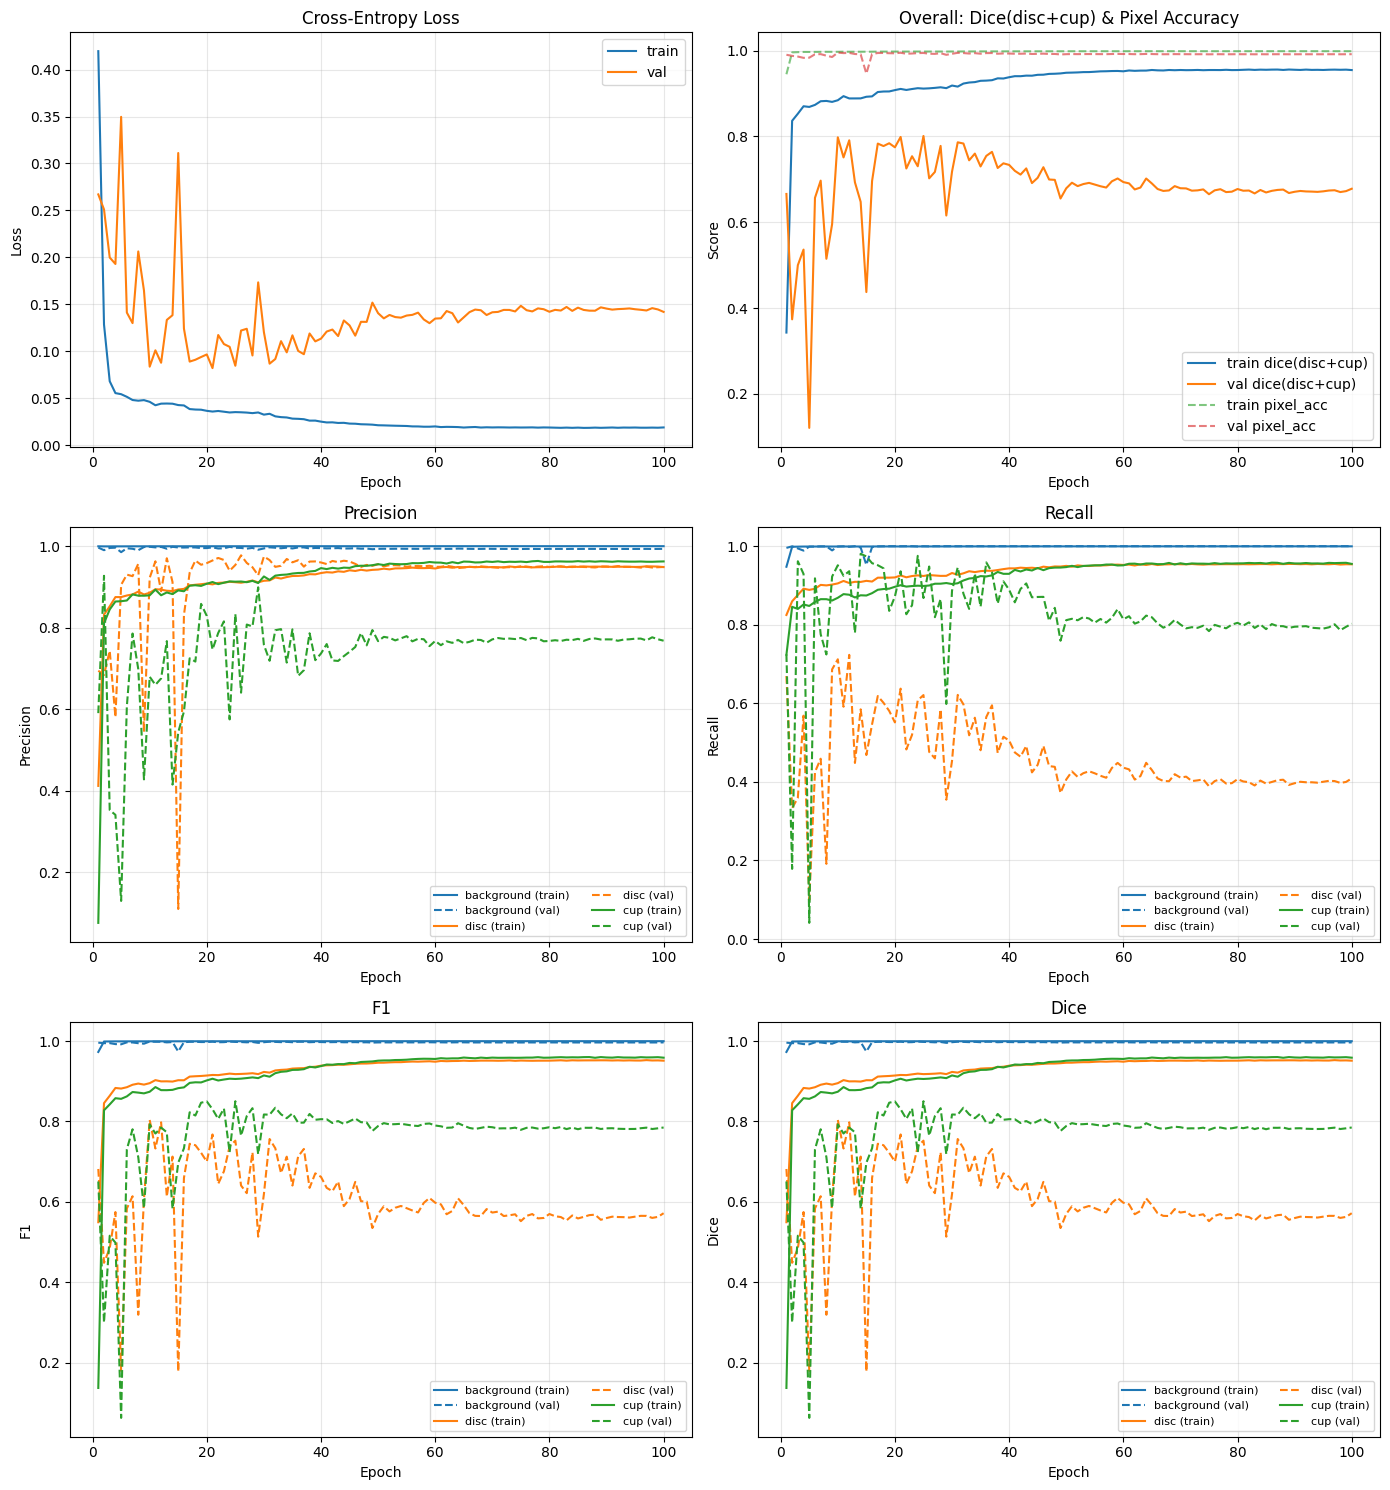

In [25]:
import matplotlib.pyplot as plt

# history["train_metrics"] / ["val_metrics"] are lists of the dict returned
# by ConfusionMatrixMeter.compute() at each epoch. Pull out each metric
# across all epochs, per class, so we can plot a curve for every one.

epochs_range = range(1, len(history["train_loss"]) + 1)
class_names = ["background", "disc", "cup"]
per_class_metrics = ["precision_per_class", "recall_per_class", "f1_per_class", "dice_per_class"]

def get_curve(split, key, class_idx=None):
    """split: 'train_metrics' or 'val_metrics'. key: metric name.
    class_idx given -> per-class curve, else scalar (e.g. macro/loss)."""
    vals = history[split]
    if class_idx is not None:
        return [m[key][class_idx] for m in vals]
    return [m[key] for m in vals]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# 1. Loss
ax = axes[0, 0]
ax.plot(epochs_range, history["train_loss"], label="train")
ax.plot(epochs_range, history["val_loss"], label="val")
ax.set_title("Cross-Entropy Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3)

# 2. Pixel accuracy + macro dice + disc/cup mean dice (overall summary)
ax = axes[0, 1]
ax.plot(epochs_range, get_curve("train_metrics", "dice_disc_cup_mean"), label="train dice(disc+cup)")
ax.plot(epochs_range, get_curve("val_metrics", "dice_disc_cup_mean"), label="val dice(disc+cup)")
ax.plot(epochs_range, get_curve("train_metrics", "pixel_accuracy"), "--", label="train pixel_acc", alpha=0.6)
ax.plot(epochs_range, get_curve("val_metrics", "pixel_accuracy"), "--", label="val pixel_acc", alpha=0.6)
ax.set_title("Overall: Dice(disc+cup) & Pixel Accuracy")
ax.set_xlabel("Epoch"); ax.set_ylabel("Score"); ax.legend(); ax.grid(alpha=0.3)

# 3-6. One subplot per metric, all 3 classes, train vs val
metric_titles = {
    "precision_per_class": "Precision",
    "recall_per_class": "Recall",
    "f1_per_class": "F1",
    "dice_per_class": "Dice",
}
positions = [(1, 0), (1, 1), (2, 0), (2, 1)]

for (row, col), metric_key in zip(positions, per_class_metrics):
    ax = axes[row, col]
    for class_idx, cname in enumerate(class_names):
        train_curve = get_curve("train_metrics", metric_key, class_idx)
        val_curve = get_curve("val_metrics", metric_key, class_idx)
        line, = ax.plot(epochs_range, train_curve, label=f"{cname} (train)")
        ax.plot(epochs_range, val_curve, "--", color=line.get_color(), label=f"{cname} (val)")
    ax.set_title(metric_titles[metric_key])
    ax.set_xlabel("Epoch"); ax.set_ylabel(metric_titles[metric_key])
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /content/training_curves.png")